# ResNet Experiments: CIFAR10 Stem 

In [1]:
# imports
import torch
import numpy as np
import torchvision
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data.dataloader import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline

## Initializing Datasets & DataLoaders

In [2]:
from torchvision import datasets, transforms

# statistics for CIFAR10 for the ResNet model preprocessing
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# get cifar10 datatset, both train and test
train_dataset = CIFAR10(root='/data', download=True, train=True,transform=train_transform)
test_dataset = CIFAR10(root='/data', download=True, train=False,transform=test_transform)
len(train_dataset), len(test_dataset)

C:\Users\shehe\projects\ai-paper-reproductions\resnet\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


(50000, 10000)

In [3]:
# global random seed for all experiments to ensure reproducibility
seed = 42
torch.manual_seed(seed)
g = torch.Generator()
g.manual_seed(seed)

In [4]:
from torch.utils.data import random_split

val_size = 10000
train_size = len(train_dataset) - val_size

train_ds, val_ds = random_split(train_dataset, [train_size, val_size], generator=g)

In [5]:
# DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, generator=g)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=True, num_workers=0, generator=g)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

# check
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

images, labels = next(iter(test_loader))
print(images.shape, labels.shape)

torch.Size([128, 3, 32, 32]) torch.Size([128])
torch.Size([128, 3, 32, 32]) torch.Size([128])


## Model Setup

In [6]:
# get the model
import sys
import os

# Adds the parent directory to the python path
sys.path.append(os.path.abspath('..'))
from models.resnet import resnet18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet18(num_classes=10)
model = model.to(device)

## Training Components

This is strickly for the overfitting check, to ensure model correctness.

In [7]:
from torch import nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=0.0
)

# scheduler
num_epochs = 15
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

### Overfit the Model with 1 Batch of Images

In [8]:
# chosen batch
batch = next(iter(train_loader))

# train endlessly
num_epochs = 30
for epoch in range(num_epochs):

    model.train()

    # training loop
    running_loss = 0.0
    correct = 0
    total = 0
    inputs, targets = batch
    inputs, targets = inputs.to(device), targets.to(device)

    # forward
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # training metrics
    running_loss += loss.item() * inputs.size(0)
    _, predicted = outputs.max(1)
    total += targets.size(0)
    correct += predicted.eq(targets).sum().item()
    
    # Validation and tracking metrics phase
    train_loss = running_loss / total
    train_acc = correct / total
    
    # print epoch metric info
    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"\tTrain   Loss: {train_loss:.4f} | Train   Acc: {train_acc:.4f}")
   


Epoch 1/30:
	Train   Loss: 2.4646 | Train   Acc: 0.1094
Epoch 2/30:
	Train   Loss: 1.2020 | Train   Acc: 0.8516
Epoch 3/30:
	Train   Loss: 0.5767 | Train   Acc: 0.9844
Epoch 4/30:
	Train   Loss: 0.2000 | Train   Acc: 1.0000
Epoch 5/30:
	Train   Loss: 0.0877 | Train   Acc: 1.0000
Epoch 6/30:
	Train   Loss: 0.0472 | Train   Acc: 1.0000
Epoch 7/30:
	Train   Loss: 0.0284 | Train   Acc: 1.0000
Epoch 8/30:
	Train   Loss: 0.0183 | Train   Acc: 1.0000
Epoch 9/30:
	Train   Loss: 0.0123 | Train   Acc: 1.0000
Epoch 10/30:
	Train   Loss: 0.0086 | Train   Acc: 1.0000
Epoch 11/30:
	Train   Loss: 0.0064 | Train   Acc: 1.0000
Epoch 12/30:
	Train   Loss: 0.0050 | Train   Acc: 1.0000
Epoch 13/30:
	Train   Loss: 0.0039 | Train   Acc: 1.0000
Epoch 14/30:
	Train   Loss: 0.0032 | Train   Acc: 1.0000
Epoch 15/30:
	Train   Loss: 0.0026 | Train   Acc: 1.0000
Epoch 16/30:
	Train   Loss: 0.0022 | Train   Acc: 1.0000
Epoch 17/30:
	Train   Loss: 0.0019 | Train   Acc: 1.0000
Epoch 18/30:
	Train   Loss: 0.0016 | Tra

### Overfit small-batch check:
- Fixed batch of 128 images
- No augmentation
- Fresh model/optimizer
- Reached 100% training accuracy by epoch 4
- Final loss at epoch 30: 0.0004

Conclusion:
The implementation and optimization pipeline are correct; the model can memorize a tiny dataset as expected.

## Experiment CIFAR10 Stem 

### Training Components

In [9]:
from torch import nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# model creation
cifar10_stem_model = resnet18(num_classes=10, stem_type="cifar10")
cifar10_stem_model = cifar10_stem_model.to(device)

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(
    cifar10_stem_model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4
)

# scheduler
num_epochs = 15
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

def recorded_time(elapsed_time):
    minutes = int(elapsed_time // 60)
    seconds = round((elapsed_time / 60 - minutes) * 60)
    print(f"time: {minutes}m {seconds}s")

### Training and Validation

In [10]:
from models.resnet import fit
from time import time

# training
start_time = time() # start the timer
history = fit(
    cifar10_stem_model,
    num_epochs,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device
)
elapsed = time() - start_time    
recorded_time(elapsed)

Epoch 1/15:
	Train   Loss: 1.8180 | Train   Acc: 0.3295
	Val     Loss: 1.5376   | Val     Acc: 0.4247
Epoch 2/15:
	Train   Loss: 1.3906 | Train   Acc: 0.4858
	Val     Loss: 1.2739   | Val     Acc: 0.5438
Epoch 3/15:
	Train   Loss: 1.1344 | Train   Acc: 0.5910
	Val     Loss: 1.0219   | Val     Acc: 0.6377
Epoch 4/15:
	Train   Loss: 0.9545 | Train   Acc: 0.6619
	Val     Loss: 1.0229   | Val     Acc: 0.6434
Epoch 5/15:
	Train   Loss: 0.8198 | Train   Acc: 0.7117
	Val     Loss: 0.7805   | Val     Acc: 0.7202
Epoch 6/15:
	Train   Loss: 0.6120 | Train   Acc: 0.7857
	Val     Loss: 0.6089   | Val     Acc: 0.7906
Epoch 7/15:
	Train   Loss: 0.5589 | Train   Acc: 0.8045
	Val     Loss: 0.5828   | Val     Acc: 0.7913
Epoch 8/15:
	Train   Loss: 0.5309 | Train   Acc: 0.8161
	Val     Loss: 0.5677   | Val     Acc: 0.7996
Epoch 9/15:
	Train   Loss: 0.5058 | Train   Acc: 0.8229
	Val     Loss: 0.5459   | Val     Acc: 0.8084
Epoch 10/15:
	Train   Loss: 0.4848 | Train   Acc: 0.8307
	Val     Loss: 0.5377   |

### Test

images.shape: torch.Size([128, 3, 32, 32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].


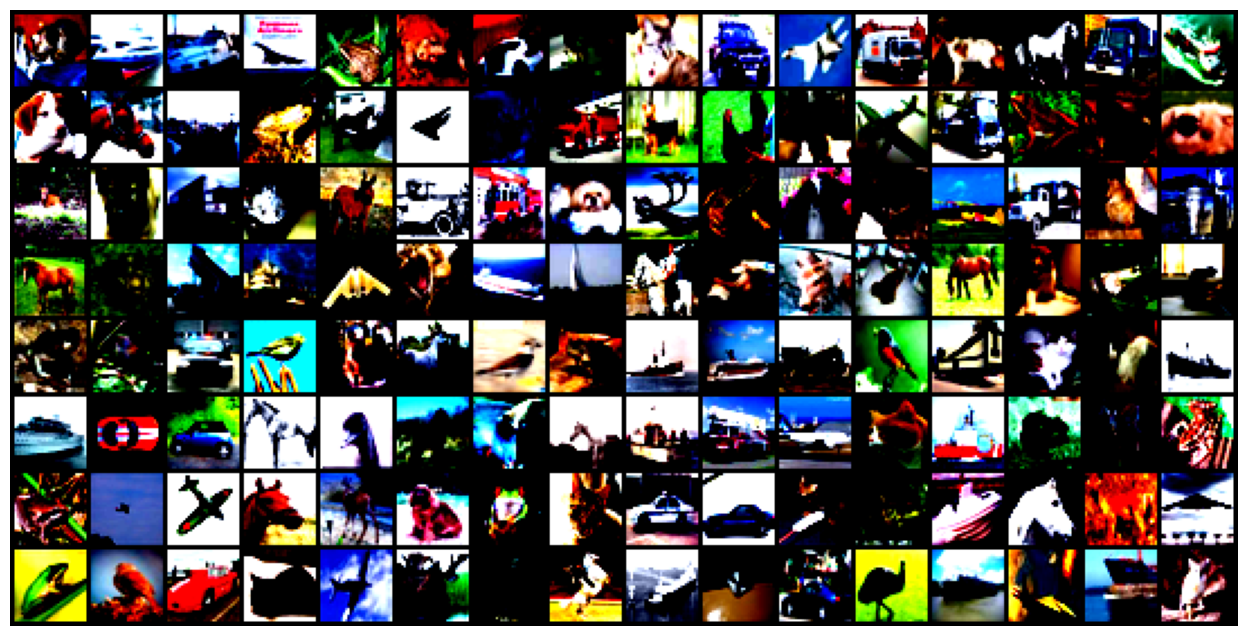

In [11]:
from torchvision.utils import make_grid

for images, _ in test_loader:
    print('images.shape:', images.shape)
    plt.figure(figsize=(16,8))
    plt.axis('off')
    plt.imshow(make_grid(images, nrow=16).permute((1,2,0)))
    break

In [13]:
from models.resnet import evaluate

# test
result = evaluate(cifar10_stem_model, test_loader, criterion, device)
print(f"Test loss: {result[0]:.4f}, Test acc: {result[1]:.4f}")

Test loss: 0.4947, Test acc: 0.8329


## Results

In [18]:
# make data of training and validtion for loss and accuracy plots

train_metrics = history['training']
val_metrics = history['validation']

train_loss = [ loss for loss,_ in train_metrics]
train_acc = [ acc for _,acc in train_metrics]

val_loss = [ loss for loss,_ in val_metrics]
val_acc = [ acc for _,acc in val_metrics]
    

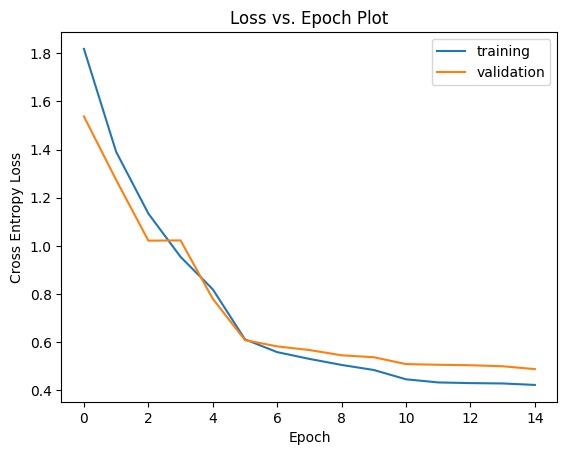

In [19]:
import matplotlib.pyplot as plt
# make plot for loss

plt.plot(train_loss, label="training")
plt.plot(val_loss, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Loss vs. Epoch Plot")
plt.legend()
plt.savefig('./images/baseline_loss_plot.png')
plt.show()

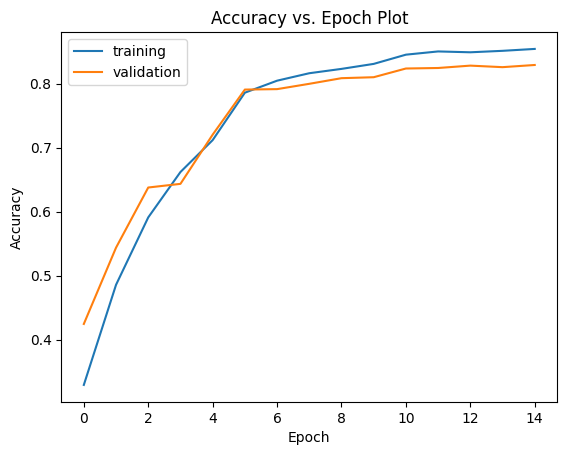

In [20]:
import matplotlib.pyplot as plt
# make plot for accuracy

plt.plot(train_acc, label="training")
plt.plot(val_acc, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Epoch Plot")
plt.legend()
plt.savefig('./images/baseline_accuracy_plot.png')
plt.show()

## Discussion/Notes
Experiment 1: CIFAR Stem
Change:
- 7x7 stride-2 conv + maxpool to 3x3 stride-1 conv, no maxpool

Result:
- Baseline test acc: 69.76%
- CIFAR stem test acc: 83.29%
- Improvement: +13.53 percentage points
- Runtime increased from 53m to 239m

Conclusion:
Adapting the ResNet stem to the input resolution is crucial. The ImageNet-style stem downsamples CIFAR-10 too aggressively, while the CIFAR-style stem preserves spatial detail and substantially improves performance.

## Save Model

In [22]:
# Save the weights to a file
torch.save(cifar10_stem_model.state_dict(), './model-weights/cifar10_stem_resnet18.pth')